In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_model_probabilities import *
color = {'f115w':'c', 'f150w':'pink','concat':'k'}


import scienceplots
plt.style.use(["science","grid"])

ImportError: cannot import name 'prepare_dataloaders' from 'dataset' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/dataset/__init__.py)

Paper Plots
-----------
In various notebooks i have carried out some tests, etc, in this notebook, i 
bring together all the plots that i have done and put the code here for 
the paper. This requires
- all_models_concat_zs_results.pkl
- probs_for_cross_concat_nob1.pkl
- model_on_data.pkl
- source_redshift_concat_test.pkl
- shape_measurement_concat_test.pkl
- latent_space.pkl


# Data plots

## Intrinsic ellipticity distribution 
----
This requires a2744_f115w_filtered.fits and a2744_f150w_filtered.fits

9737 galaxies in common
1889 extra galaxies in cat_a
4107 extra galaxies in cat_b
15733 total galaxies
PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/intrinsic_ell.pdf'.


0

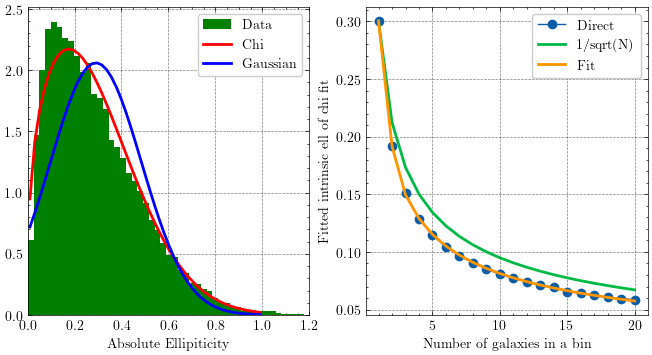

In [8]:
filter_list = ['concat']
fig,axarr=plt.subplots(len(filter_list),2, figsize=(8,4))
nbins=50
if len(filter_list ) == 1:
    axarr = axarr[None,:]

for ifx, ifilter in enumerate( filter_list): 
    if ifilter=='concat':
        cat_a_name =     f"../data/a2744/a2744_f115w_filtered.fits"
        cat_b_name =     f"../data/a2744/a2744_f150w_filtered.fits"
        obs_data = combine_catalogues( cat_a_name, cat_b_name, identifier='NUMBER' )
    else:
        obs_data = fits.open(f"../data/obs/a2744_{ifilter}_filtered.fits")[1].data
    ax=axarr[ifx]
    
    x = np.linspace(0,1,nbins)
    data = np.sqrt(obs_data['e1']**2+obs_data['e2']**2)
    ax[0].hist(data, density=True,bins=nbins,label='Data',color='g')

    gaussian_assumption = np.sqrt( 
        norm.rvs( *norm.fit(obs_data['e1']), 2*obs_data['e1'].shape[0])**2 +
        norm.rvs( *norm.fit(obs_data['e2']), 2*obs_data['e1'].shape[0])**2 
    )

    y, x = np.histogram(gaussian_assumption,bins=x,density=True)

    xc = (x[1:] + x[:-1])/2.

    #ax[0].step( xc, y ,label='Gaussian', lw=2)

    #ax[1].plot(np.linspace(-1,1,nbins), 
     #          norm.pdf(np.linspace(-1,1,nbins), *norm.fit(obs_data['e1'])), 
      #         label='Gaussian', lw=2)
    
    ervs = chi.rvs( *chi.fit(data),  int(data.shape[0]))

    theta = np.random.uniform(0,np.pi, int(data.shape[0]))
    e1 = ervs*np.cos(2.*theta)
    e2 = ervs*np.sin(2.*theta)
    g = np.sqrt(e1**2+e2**2)
    y, x = np.histogram( e1*2/(1+g**2), density=True, bins=np.linspace(-1,1,nbins) )
    
    obsshear = np.sqrt(obs_data['e1']**2+obs_data['e2']**2)
    
    ax[0].plot( xc, chi.pdf(xc, *chi.fit(data)), color='r',label='Chi',lw=2)
    ax[0].plot( xc, norm.pdf(xc, *norm.fit(data)), color='b',label='Gaussian',lw=2)
  
    
    
    ax[1].set_ylabel("Probability Distribution")


    ax[0].set_xlabel("Absolute Ellipiticity")
    ax[0].set_xlim(0,1.2)
    ax[0].legend()

    nmonte = 10000
    intrinsic_ell = []
    ngal_range = np.arange(20)+1
    for ngal in ngal_range:
        rdn_ells = []
        for imonte in range(nmonte):
            rdn_idx = np.random.choice(
                np.arange(obs_data['e1'].shape[0]),
                size=ngal
            )

            e1rdn = np.mean(obs_data['e1'][rdn_idx])
            e2rdn = np.mean(obs_data['e2'][rdn_idx])



            rdn_ells.append(np.sqrt(e1rdn**2+e2rdn**2))

        fit = chi.fit(rdn_ells)[2]

        intrinsic_ell.append(fit)
    intrinsic_ell = np.array(intrinsic_ell)
    ax[1].plot(
        ngal_range, intrinsic_ell, '-o', label='Direct'
    )
    ax[1].plot(
        ngal_range, intrinsic_ell[0]/np.sqrt(ngal_range), '-',label='1/sqrt(N)', lw=2
    )


    ax[1].set_xlabel("Number of galaxies in a bin")
    ax[1].set_ylabel("Fitted intrinsic ell of chi fit")
    ratio =  (intrinsic_ell[0]/np.sqrt(ngal_range)) / intrinsic_ell

   

    def g1_func( snr, a, b, c, d):

        return a + b*np.arctan( ( snr - c)/d)



    popt, pcov = curve_fit(
                    g1_func,
                    ngal_range,
                    ratio)

  
    ax[1].plot(
        ngal_range, intrinsic_ell[0]/(g1_func( ngal_range, *popt)*np.sqrt(ngal_range)), label='Fit', lw=2
    )
    ax[1].legend()
filename = "plots/intrinsic_ell.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))

## Postage stamp examples

### Get the ideal data

In [9]:
args = get_temp_args()
args.source_domain = 'bahamas'
args.target_domain = 'darkskies'
args.apply_intrinsic_ell=0
ideal_data = prepare_dataloaders(args)

In [10]:
for i in ideal_data.keys():
    ideal_data[i][0].dataset.dataset.transform.transforms[2].apply = 0
    if 'source' in i:
        ideal_src = ideal_data[i][0].dataset.dataset[0]
    if 'target' in i:
        ideal_tgt = ideal_data[i][0].dataset.dataset[0]

### Now get the obs sampled data

In [11]:
idx=0

In [12]:
args.source_domain = 'bahamas_obs'
args.target_domain = 'darkskies_obs'
obs_sampled_data = prepare_dataloaders(args)

In [13]:
for i in obs_sampled_data.keys():
    obs_sampled_data[i][0].dataset.dataset.transform.transforms[2].apply = 0
    if 'source' in i:
        obs_sampled_src = obs_sampled_data[i][0].dataset.dataset[idx]
    if 'target' in i:
        obs_sampled_tgt = obs_sampled_data[i][0].dataset.dataset[idx]

In [14]:
for i in obs_sampled_data.keys():
    obs_sampled_data[i][0].dataset.dataset.transform.transforms[2].apply = 1.
    if 'source' in i:
        obs_noisy_src = obs_sampled_data[i][0].dataset.dataset[idx]
    if 'target' in i:
        obs_noisy_tgt = obs_sampled_data[i][0].dataset.dataset[idx]

In [15]:
obs_meta, obs_data = pkl.load(open(f"../data/a2744/obs_data_concat.pkl","rb"))
obs_cat = combine_catalogues(
    "../data/a2744/a2744_f115w_filtered.fits",
    "../data/a2744/a2744_f150w_filtered.fits"
)


9737 galaxies in common
1889 extra galaxies in cat_a
4107 extra galaxies in cat_b
15733 total galaxies


### Now plot

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/data_examples.pdf'.


0

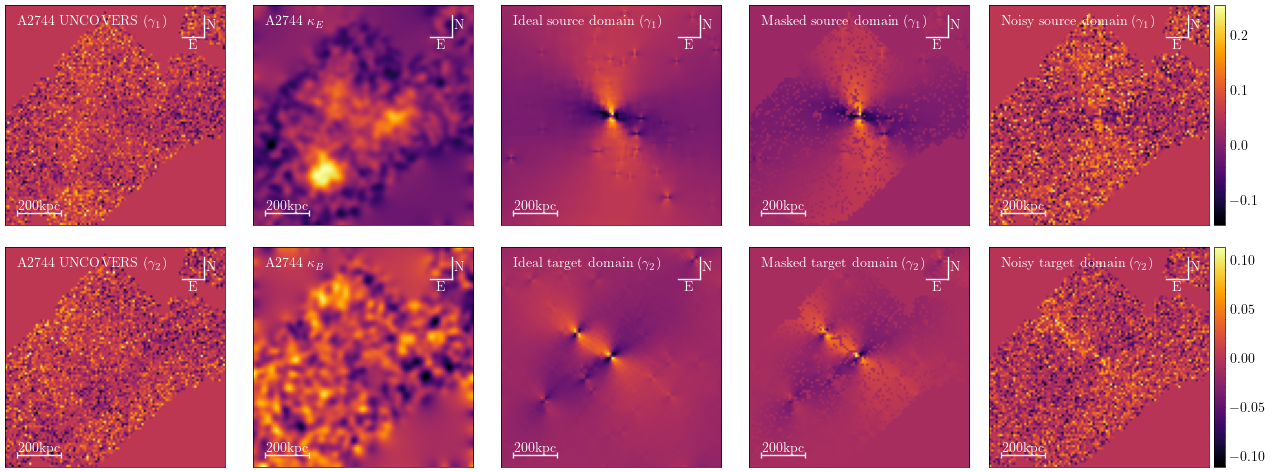

In [16]:
fig, ax = plt.subplots(2, 5, figsize=(16,6))
fig.subplots_adjust(hspace=0.1,wspace=0.)
cmap='inferno'
ax[0,2].imshow(ideal_src[0][0], cmap=cmap, origin='lower')
ax[0,2].text( 5, 90, 'Ideal source domain ($\gamma_1$)', color='white', fontweight='bold')

ax[1,2].imshow(ideal_tgt[0][1], cmap=cmap, origin='lower')
ax[1,2].text( 5, 90, 'Ideal target domain ($\gamma_2$)', color='white', fontweight='bold')

ax[0,3].imshow(obs_sampled_src[0][0], cmap=cmap, origin='lower')
ax[0,3].text( 5, 90, 'Masked source domain ($\gamma_1$)', color='white', fontweight='bold')

ax[1,3].imshow(obs_sampled_tgt[0][1], cmap=cmap, origin='lower')
ax[1,3].text( 5, 90, 'Masked target domain ($\gamma_2$)', color='white', fontweight='bold')

ax[0,4].imshow(obs_noisy_src[0][0], cmap=cmap, origin='lower')
ax[0,4].text( 5, 90, 'Noisy source domain ($\gamma_1$)', color='white', fontweight='bold')

ax[1,4].imshow(obs_noisy_tgt[0][1], cmap=cmap, origin='lower')
ax[1,4].text( 5, 90, 'Noisy target domain ($\gamma_2$)', color='white', fontweight='bold')


ax[0,0].imshow(obs_data[0][0], cmap=cmap, origin='lower')
ax[0,0].text( 5, 90, 'A2744 UNCOVERS ($\gamma_1$)', color='white', fontweight='bold')

ax[1,0].imshow(obs_data[0][1], cmap=cmap, origin='lower')
ax[1,0].text( 5, 90, 'A2744 UNCOVERS ($\gamma_2$)', color='white', fontweight='bold')

if np.max(obs_cat['x']) > 1000:
    ra,dec = ra_dec_to_simulation_image_pos( obs_cat)
    obs_cat['x'] = ra
    obs_cat['y'] = dec
image_size  = 100
kappa_e, kappa_b = get_kappa(
    obs_cat, smooth=1.5, extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
)

im2 = ax[0,1].imshow(kappa_e, cmap=cmap, origin='lower')
ax[0,1].text( 5, 90, 'A2744 $\\kappa_E$', color='white', fontweight='bold')
divider = make_axes_locatable(ax[0,4])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical')

im2 =ax[1,1].imshow(kappa_b, cmap=cmap, origin='lower')
ax[1,1].text( 5, 90, 'A2744 $\kappa_B$', color='white', fontweight='bold')

divider = make_axes_locatable(ax[1,4])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical')


for iax in ax.flatten():
    iax.set_xticklabels([])
    iax.set_yticklabels([])
    iax.errorbar( 15, 5,xerr=10, capsize=2, color='white')
    iax.text( 15, 5, '200kpc', ha='center', va='bottom', color='white')
    iax.plot([ 80, 90], [85,85], '-', color='white')
    iax.plot([90, 90],[95, 85], '-', color='white')
    iax.text( 85, 84, 'E', ha='center', va='top', color='white')
    iax.text( 91, 90, 'N', ha='left', va='center', color='white')
    iax.set_xticks([])
    iax.set_yticks([])
    
filename = "plots/data_examples.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))

# Domain Adaptation

[0.6010047928695907, 0.5578445060844193]
[0.6225849362621765, 0.5362643626918335]
PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/final_model_weighting_with_data.pdf'.


0

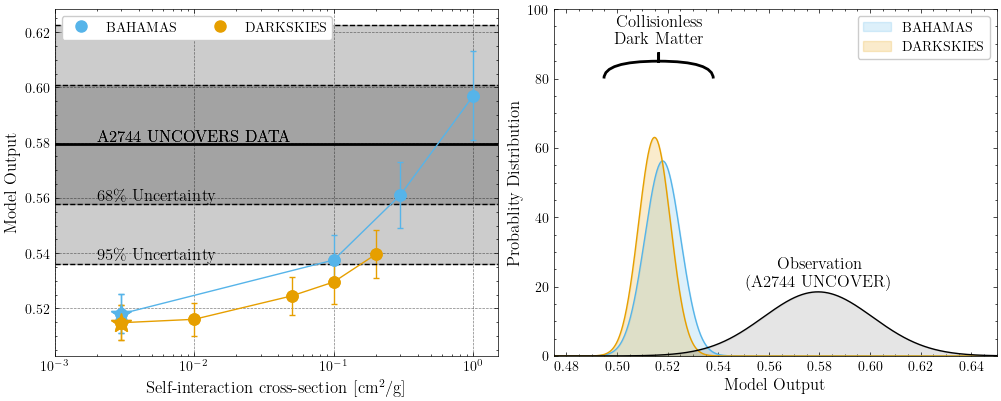

In [18]:
config='baha2dark'
filter_list  = ['concat']
cdm = 3e-3

color = {
        'src':'r',
        'tgt':'b'
    }

domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


correction = 2.
### MASS WEIGHTS FOR CALCULATING THE MEAN #####
zs = 1.65
zl = 0.305
critical_density = sigma_critical(zl, zs, Planck18).to(units.Msun/units.kpc/units.kpc)

bah_meta, bah_data = pkl.load(open("../data/shear/bahamas_cdm.pkl","rb"))
dar_meta, dar_data = pkl.load(open("../data/shear/darkskies_cdm.pkl","rb"))
mass_bah = np.log10(np.sum(np.sum(bah_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)
mass_dark = np.log10(np.sum(np.sum(dar_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)

yb, x = np.histogram(mass_bah, bins=np.linspace(14,15.5,30))
yb[ yb == 0] = 1
yd, x = np.histogram(mass_dark, bins=np.linspace(14,15.5,30))
yd[yd==0] = 1
mass_weights = {'src':{'x':x, 'y':1./yb},'tgt':{'x':x, 'y':1./yd}} 
#######




fig, axarr = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)

ifilter = 'concat'

all_results = pkl.load(open(f"pickles/all_models_{ifilter}_zs_results.pkl",'rb'))

postive_mass, mass_cut = get_mass_cut( ifilter, nsigma=1., study='harvey' )


mass_cut = [ i for i in mass_cut]


this_domain = [    {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    }, {
    'tgt':'flamingo_obs',
    'src':'tng_obs'
    }
    
]
fiducial = f"pickles/all_models_{ifilter}_zs_results.pkl"
tng_flamingo = f"pickles/flamingo_tng_results.pkl"

colors = {
    'flamingo':'cyan', 'bahamas':'r', 'darkskies':'b','tng':'green'}

cdm_vals = []
for ifx, results_file in enumerate( [fiducial]):
    domain = this_domain[ifx]
    
    all_results= pkl.load(open(results_file,'rb'))
    
    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []

        domain_name = domain[target].split('_')[0]
        for imodel in all_results.keys():

            seed = float(imodel.split('_')[1])                


            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                integrated_mass=True,
                function=np.mean,
                mass_weights=None, #mass_weights[target],
                dataset=domain[target].split('_')[0],
                quiet=False)


            all_thresholds.append(tgt['thresholds'])

        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction

        cdm_vals.append(1-means[0])

        if len(tgt['cross_sections']) > 1:
            tgt['cross_sections'][0] += cdm
            axarr[0].errorbar( tgt['cross_sections'], 
                       1-means,
                        errors,
                        fmt='-o', 
                        capsize=2,
                        markersize=8, color=colour_scheme[domain_name.lower()])
            axarr[0].plot( tgt['cross_sections'], 
                       1-means, 'o', label=f"{domain_name.upper()}", 
                        markersize=8, color=colour_scheme[domain_name.lower()])

            axarr[0].errorbar( cdm, 
                       1-means[0],
                        errors[0],
                        fmt='*', 
                        capsize=2,
                        markersize=15, color=colour_scheme[domain_name.lower()])


            axarr[0].plot( cdm, 
                       1-means[0],
                        '*', 
                        markersize=15, color=colour_scheme[domain_name.lower()])


            axarr[0].set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        npts = 1000
        xpdf = np.linspace(0.45,0.7, npts)

        ypdf = norm.pdf( xpdf, *(1-means[0], errors[0]))

        axarr[1].plot(  xpdf, ypdf,
                         color=colour_scheme[f"{domain[target].split('_')[0].lower()}"])

        axarr[1].fill_between( xpdf,
                        ypdf,
                        np.zeros(npts),
                         color=colour_scheme[f"{domain[target].split('_')[0].lower()}"],
                       alpha=0.2, label=domain[target].split('_')[0].upper())


        axarr[1].set_xlabel("Model Output", fontsize=12)
        axarr[1].set_ylabel("Probablity Distribution", fontsize=12)

        axarr[1].set_xlim(0.475, 0.65)

axarr[0].set_xscale('log')

axarr[0].set_xlabel("Self-interaction cross-section [cm$^2$/g]", fontsize=12)
axarr[0].set_ylabel("Model Output", fontsize=12)

#
axarr[0].set_xlim(1e-3,1.5)
#axarr[0].text(0.7,0.05,f"Noise Floor", transform=axarr[0].transAxes,fontsize=12, ha='left')
axarr[0].set_xscale('log')


plot_observations( "pickles/model_on_data.pkl", ifilter, ax=axarr[0], correction=correction, 
                  plot_args={'lw':2, 'color':'k'}, fill_args={'alpha':0.2, 'color':'k'},
                  uncertainty=[68,95])
#plot_observations( "pickles/model_on_data.pkl", ifilter, ax=axarr[0], correction=correction, 
#                  plot_args={'lw':2, 'color':'k','ls':'--'}, fill_args={'alpha':0.1, 'color':'b'},
#                   noise=True )
#plot_observations( "pickles/model_on_data.pkl", ifilter, ax=ax, noise=True, legend=False, **{'label':'Noise','color':'k'} )
axarr[0].legend(loc=2,ncols=2)

plot_observations( "pickles/model_on_data.pkl", ifilter, ax=axarr[1], correction=correction, 
                  plot_args={'lw':2, 'color':'k'}, fill_args={'alpha':0.1, 'color':'k'}, plotpdf=True)

edges = [np.min(cdm_vals)-0.02, np.max(cdm_vals)+0.02]
curly_brace(axarr[1], edges[0], edges[1], 80, 10, upward=True)
axarr[1].text(np.mean(edges), 90, "Collisionless \n Dark Matter", ha='center', fontsize=12)       

axarr[1].text(0.58, 20, "Observation \n (A2744 UNCOVER)", ha='center', fontsize=12)      

axarr[1].grid(False)
axarr[1].set_ylim(0, 100)

axarr[1].legend()
  
fig.align_xlabels()

filename = "plots/final_model_weighting_with_data.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))
 

# Applying to data 
-----

I need to show that (since SIDM broadens the distirbution) that in CDM it is inconsistent and deviates away, but in strong SIDM, it is no longer consistent with a random distribution  - i.e. the deviations are too small)

Show the consistency with simulations plot - requires (both found in respexctive notebooks)
- model_on_data.pkl
- probs_for_cross_{ifilter}_nob1.pkl

# Fit a line to the points.

In [19]:
def g1_func( snr, a, b, c, d ):
    return a + b*np.exp( snr /c) + d*snr
    #return a + b*snr + c*snr**2
    #return a+b*snr

def g1_inv( snr, a, b, c, d):
    
    #return np.log((snr - a)/b)*c
    
    z =  b/(c*d)*np.exp((snr-a)/(c*d))
    
    return ( snr - a)/d - c*lambertw(z)
    #return (snr -a)/b
    
def jacob( snr, a, b, c, d):

    z = b/(c*d)*np.exp((snr-a)/(c*d))
    
    deriv = 1. / (d*(1+lambertw(z) ))
    #deriv = c*lambertw(z) / (z*(1+lambertw(z) ))
    return deriv

    #return c/(snr-a)
    #return 1./b

$a=0.54\pm0.048$, $b=0.065\pm0.047$, $c=0.56\pm0.49$, $d=0.01\pm0.021$
$\chi=1.6\pm1e+00$
$\sigma_{\rm CDM}=0.003$\cpg
(-0.2557453870140711+0j) - (0.33242105277826606+0j) + (0.21456965766875546+0j)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/output_to_model.pdf'.


0

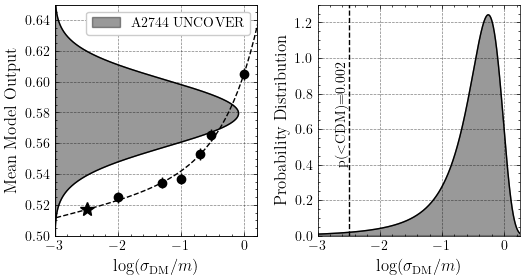

In [20]:
fig, axarr = plt.subplots(1, 2,figsize=(6,3))
fig.subplots_adjust(hspace=0.25)
handles = []
filter_list = ['concat']
color = {'f115w':'c', 'f150w':'pink','concat':'k'}
for ifx, ifilter in enumerate(filter_list):


    models, probs = pkl.load(open(f"pickles/probs_for_cross_{ifilter}_nob1.pkl","rb"))
    models, probabilities, probabilities_noise = pkl.load(open("pickles/model_on_data.pkl","rb"))
    nmodels = probabilities[ifilter].shape[0]

    thresholds = 1.-np.array([ np.mean(np.concatenate([ j for j in probs[i]])) for i in probs.keys()])

    err = np.array([ np.std(np.concatenate([ j for j in probs[i]]))/np.sqrt(300.) for i in probs.keys()])
    cross = np.array([float(i) for i in probs.keys() ])

    cdm_thresh = thresholds[ cross == 0]
    cdm_err = err[ cross == 0]


    err = err[ cross != 0 ]
    thresholds = thresholds[ cross != 0 ]
    cross = cross[ cross != 0]

    #cross[cross==0] = 1e-3
    cross = np.log10(cross)



    ## CURVE FITTING
    popt, pcov = curve_fit(
                g1_func,
                cross,
                thresholds,
                sigma=err,
                bounds=(np.array([-np.inf,-np.inf,-np.inf,0.01]),
                        np.array([np.inf, np.inf, np.inf, np.inf])
                        ))

    popt_err = np.sqrt(np.diag(pcov))
    name =['a','b','c','d']
    print(', '.join([ f"${name[i]:0.2}={popt[i]:0.2}\pm{popt_err[i]:0.2}$" for i in range(len(popt))]))
    dof = cross.shape[0] - len(name)
    
    chi = np.sum( (thresholds - g1_func(cross, *popt))**2/err**2)/dof

    chierr = np.sqrt(2./dof)
    print(f'$\chi={chi:0.2}\pm{chierr:0.1}$')
    cdm_cross = g1_inv( cdm_thresh, *popt).real


    
    fig.subplots_adjust(wspace=0.3)
    
    if ifilter == 'concat':
    #####################

    ###PLOT 1

    #####################
        ax = axarr[0]
        ax.errorbar(cross,thresholds,err,fmt='o', color=color[ifilter])
        ax.plot( cdm_cross, cdm_thresh, '*', ms=10, color=color[ifilter])
        xplot=np.linspace(-5.4,1,100)
        ax.plot( xplot, g1_func(xplot, *popt),'--', color=color[ifilter])
        ax.set_xlim(-3,0.2)
        ax.set_xlabel("log($\sigma_{\\rm DM}/m$)",fontsize=12)
        ax.set_ylabel("Mean Model Output",fontsize=12)

        #####################

        ###PLOT 2

        #####################
        ax = axarr[0].twiny()

        xpdf = np.linspace(0.45,0.65,1000)
        thresh = 1-probabilities[ifilter]
        correction = 2.0
        corr = correction*nmodels**0.5/nmodels**0.38

        ypdf = np.prod([ norm.pdf(xpdf, i, corr*np.std(probabilities[ifilter])) for i in thresh ],axis=0)
        ypdf /= np.sum(ypdf)*(xpdf[1]-xpdf[0])

        ax.plot(ypdf[::-1], xpdf[::-1], 'k-')
        handles.append(ax.fill_between(ypdf, xpdf, alpha=0.4, label=f'A2744 UNCOVER', color=color[ifilter]))
        ax.set_xlim(0, ypdf.max()*1.1)
        ax.set_ylim(0.5, xpdf.max())




        ax.set_xticks([])
    #####################


    ###PLOT 3

    #####################
    print(f"$\\sigma_{{\\rm CDM}}={10**cdm_cross[0]:0.1}$\cpg")
    ax = axarr[1]



    #ax.plot(xpdf, ypdf,'k-')

    #xc = (x[1:] + x[:-1])/2.


    x_cross = g1_inv( xpdf, *popt)
    f_cross = ypdf  * jacob(xpdf, *popt)
    f_cross = f_cross/np.nansum(f_cross)/(x_cross-np.roll(x_cross,1))
    #print(np.sum(f_cross)*(x_cross-np.roll(x_cross,1)))
    ax.plot(x_cross, f_cross, 'k-')

    #ax.set_ylim(ax.get_ylim())
    ax.set_xlim(-3, 0.25)
   
    

    ax.set_xlabel("log($\sigma_{\\rm DM}/m)$",fontsize=12)
    ax.set_ylabel("Probability Distribution",fontsize=12)

    #ax.legend()
    max_like_log = x_cross[np.argmax(f_cross)]
    cumsum = np.nancumsum(f_cross)/np.nansum(f_cross)
    cdm_prob = cumsum[ np.nanargmin(np.abs(x_cross-cdm_cross))].real
    if len(filter_list) == 1:
        ax.text(cdm_cross,0.4,f"p($<$CDM)={cdm_prob:0.1}", rotation=90, ha='right', fontweight='bold')
        ax.fill_between(x_cross, f_cross, alpha=0.4, color=color[ifilter])
        if ifx == 0:
            ax.plot([cdm_cross,cdm_cross],[0,ax.get_ylim()[1]*1.1],'k--')
    else:
        ax.fill_between(x_cross, f_cross, alpha=0.4, label=f"p($<$CDM$_{{\\rm {ifilter}}}$)={cdm_prob:0.1}", color=color[ifilter])
        ax.legend()
    low, high = [x_cross[ np.argmin(np.abs(cumsum-0.16))], x_cross[ np.argmin(np.abs(cumsum-0.84))]]


    #ax.set_
    print(f"{max_like_log} - {max_like_log - low} + {high - max_like_log}")
    max_like = 10**max_like_log
    error = np.array([max_like - 10**low, 10**high - max_like])
    ax.set_ylim(0,1.3)
    #ax.set_
    
axarr[0].legend(handles=handles)
filename = f"plots/output_to_model.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/ma/core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


$\sigma_{\rm DM}/m=0.55_{-0.30}^{+0.35}$cm$^2$/g
PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/particle_physics.pdf'.


0

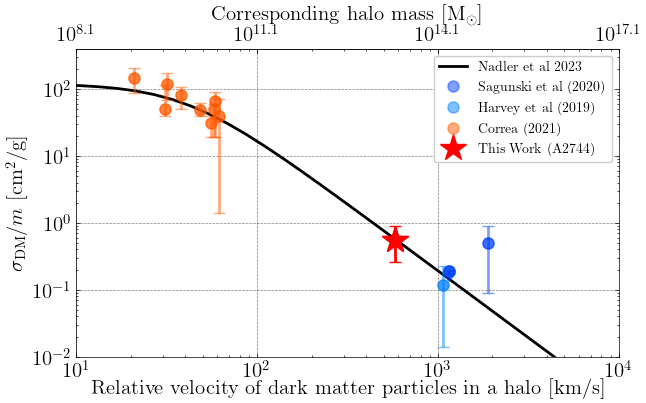

In [21]:
markersize = 12

fig = plt.figure(figsize=(7,4))
ax = plt.gca()


x = np.logspace(0,5)

ax.plot( x, sigma_vd( x, 120,40),  lw=2, color='k', label='Nadler et al 2023')


ax.set_ylabel('$\sigma_{\\rm DM}/m$ [cm$^2$/g]', fontsize=15, wrap=True)
ax.set_xlabel('Relative velocity of dark matter particles in a halo [km/s]', fontsize=15, labelpad=-2)

ax.loglog()
ax.set_ylim(1e-2,4e2)
ax.set_xlim(10,1e4)

def v_to_m(v):
    m = mass_from_velocity(v * units.km / units.s, redshift=0.3)
    return m

def m_to_v(m):
    # inverse of mass_from_velocity (using dummy v³ relation)
    v = v_from_m(m)
    return v

# Create top axis linked via transformation
top = ax.secondary_xaxis('top', functions=(v_to_m, m_to_v))
top.set_xscale('log')
top.set_xlabel('Corresponding halo mass [$\\rm M_\odot$]', fontsize=15)
#plt.text(0.5, 1.5, 'Corresponding halo mass [$\\rm M_\odot$]', fontsize=15, 
#         transform=top.transAxes, ha='center', va='bottom')


bottom_ticks = ax.get_xticks()                   # e.g., [1, 10, 100, ...]
top_ticks = v_to_m(bottom_ticks)                 # positions on top axis that correspond
top.set_xticks(top_ticks)

# Optional: set nice tick labels (e.g., log10 of mass) — choose whatever formatting you want:
top.set_xticklabels([f"{t:.1e}" for t in top_ticks])
def sci_notation(x, pos):
    if x == 0:
        return "0"
    exp = np.log10(x)
    #pre = 10**(np.log10(x) - exp)
    
    return rf"$10^{{{exp:.01f}}}$"  # e.g., 10^10, 10^11

top.xaxis.set_major_formatter(FuncFormatter(sci_notation))
#top.set_xlabel("Halo Mass $[M_\odot]$", fontsize=12)
ax.tick_params(axis='both', labelsize=15)
top.tick_params(axis='both',  labelsize=15)

plot_constraints( ax=ax, select_these=['Dwarf_correa21','cluster_harvey19','sagunski'],
                labels={'Dwarf_correa21':'Correa (2021)','cluster_harvey19':'Harvey et al (2019)', 'sagunski':'Sagunski et al (2020)'})

lower_constraints =  {'range':[1e9,1e10],'error':40.,'label':'WP1', 'plotargs':{'ls':':','color':'k', 'lw':3}}
intermediate_constraints = {'range':[3e12,8e12],'error':1.,'label':'WP1', 'plotargs':{'ls':'-','color':'k', 'lw':3}}
upper_constraints = {'range':[3e14,3e15],'error':0.05,'label':'WP2', 'plotargs':{'ls':'-','color':'k', 'lw':3}}

#plot_constraints( intermediate_constraints,upper_constraints, lower_constraints)

velocity_disp = [522, 633]
#velocity_disp = [1750, 1750]

ax.plot( np.mean(velocity_disp), max_like, '*',
            markersize=20, color='red', lw=2, label='This Work (A2744)')
ax.errorbar( np.mean(velocity_disp), max_like, yerr=error[:,None], 
            markersize=20, color='red', fmt='*', capsize=4, lw=2)

print(f"$\sigma_{{\\rm DM}}/m={max_like.real:0.2f}_{{-{error[0].real:0.2f}}}^{{+{error[1].real:0.2f}}}$cm$^2$/g")
# get handles
ax.legend()
fname = "plots/particle_physics.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

## Appendix plots

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/goodness_of_fit.pdf'.


0

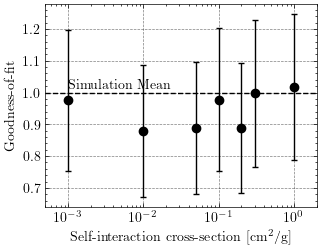

In [22]:
nmodels=30
unique_cross, latent_distances, latent_quantiles =  pkl.load(open("pickles/latent_space.pkl","rb"))
av_distances = [ np.mean([ np.mean(latent_distances[i][j]) for i in range(nmodels)]) for j in range(len(unique_cross))]
err = [ np.std([ np.mean(latent_distances[i][j]) for i in range(nmodels)]) for j in range(len(unique_cross))]
ax = plt.gca()
unique_cross[0] = 1e-3
ax.errorbar( unique_cross, av_distances, err, color='k', fmt='o', capsize=2)
ax.plot([5e-4,2],[1,1],'k--')
ax.text(0.001,1.0, 'Simulation Mean', ha='left', va='bottom')
ax.set_xlim(5e-4,2)
ax.set_xscale('log')
ax.set_ylabel("Goodness-of-fit")
ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
fname="plots/goodness_of_fit.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


2.0817337
PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/correlated_models.pdf'.


0

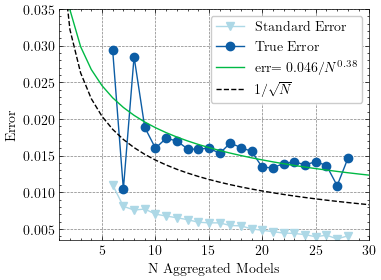

In [24]:
fig, axarr = plt.subplots(1,1,figsize=(4,3))
axarr = [axarr]
for ifx, ifilter in enumerate(['concat']):
    ax = axarr[ifx]
    model_index,probs_for_cross  = pkl.load(open(f"pickles/probs_for_cross_{ifilter}_all_nob1.pkl","rb"))

    variance = []
    stds = []
    nmodels = []
    sidm = '0.00'

    unique = np.unique(np.concatenate([ model_index[sidm][j] for j in range(len(model_index[sidm]))]))

    for jcluster in unique:    
        these_clusters = []

        for imodel in range(len(probs_for_cross[sidm])):
            idx = jcluster == model_index[sidm][imodel]

            these_clusters.append( np.mean(probs_for_cross[sidm][imodel][idx] ))


        these_clusters = np.array(these_clusters)

        variance.append(np.nanmean(these_clusters))


        nmodels.append(np.sum(np.isfinite(these_clusters)))
        stds.append(np.nanstd(these_clusters))

    variance = np.array(variance)
    nmodels = np.array(nmodels)
    stds = np.array(stds)
    all_unique_nmodels, nunique = np.unique(nmodels, return_counts=True)


    unique_nmodels = all_unique_nmodels[ (all_unique_nmodels != 0) & (nunique > 0)]

    #True variance 
    icv = np.array([ np.nanstd( variance[ i == nmodels]) for i in unique_nmodels])

    #Standard deviagtion
    ics = np.array([ np.nanmean( stds[ i == nmodels]) for i in unique_nmodels])




    standard_error = ics/np.sqrt(unique_nmodels)




    #plt.plot( unique_nmodels, error_per_model/(1.2*np.sqrt(unique_nmodels)), label="1.2 x Random")

    ax.plot( unique_nmodels, standard_error, '-v', color='lightblue', label="Standard Error")
    ax.plot( unique_nmodels, icv, '-o', label=f"True Error")


    def fit_sqrt( x, a,b ):
        return a*x**(-b)


    popt, pcov = curve_fit(
                    fit_sqrt,
                    unique_nmodels,
                    icv)    

    ax.plot( np.linspace(0,40,41), fit_sqrt(np.linspace(0,40,41),*popt), '-', label=f"err$={popt[0]:0.3f}/N^{{{popt[1]:0.2f}}}$")

    rescale = 1./standard_error[0]*fit_sqrt(unique_nmodels, *popt)

    rescaled_error = np.mean(popt[0]/icv)
    
    ax.plot( np.linspace(0,40,41), popt[0]/np.sqrt(np.linspace(0,40,41)), 'k--', label='$1/\sqrt{N}$')

    ax.legend(loc=1)
    ax.set_xlabel("N Aggregated Models")
    print(np.mean(popt[0]/ics))
    if ifx == 0:
        ax.set_ylabel("Error")
        
    ax.set_ylim(0.0035,0.035)
    ax.set_xlim(1,30)
fname="plots/correlated_models.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

### A) Source redshift dependency

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/source_redshift.pdf'.


0

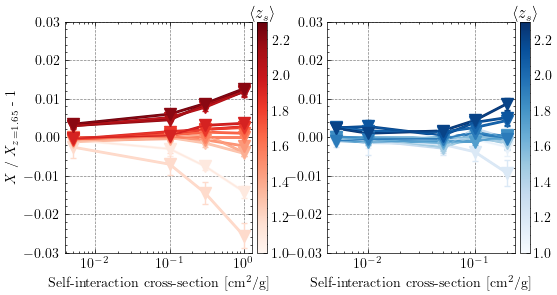

In [25]:
config='baha2dark'
filter_list  = ['concat']
cdm = 5e-3



domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


source_tests = f"pickles/source_redshift_{ifilter}_test.pkl"

all_tests = pkl.load(open(source_tests,'rb'))


fig, axarr = plt.subplots(1,2, figsize=(6,3))
fig.subplots_adjust(wspace=0.3)
ax = axarr[0]


color = {
        'src':colourFromRange([-1,len(all_tests.keys())], cmap='Reds'),
        'tgt':colourFromRange([-1,len(all_tests.keys())], cmap='Blues')
    }

fid =  all_tests[1.6]

all_zs = np.array(list(all_tests.keys()))
for izs, isource_redshift in enumerate(all_zs):
   
    
    all_results = all_tests[isource_redshift]


    

    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []
        ax = axarr[itgt]
        for imodel in all_results.keys():
            
            seed = float(imodel.split('_')[1])
  
            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)

            ref = get_threshold_for_cross( 
                fid[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)
            
            all_thresholds.append(tgt['thresholds']/ref['thresholds'])
            
        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 
        




        tgt['cross_sections'][0] += cdm
        ax.errorbar( tgt['cross_sections'], 
                    means-1,
                    errors,
                    fmt='-v', label=f"$z_s$={isource_redshift}", 
                    capsize=2,
                    markersize=8, color=color[target][izs])
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        #ax.legend(loc=3, ncols=2)
        
        points = np.column_stack([tgt['cross_sections'], means-1])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(all_zs.min(), all_zs.max()),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], isource_redshift))
        im2 = ax.add_collection(lc)
        
        
        if izs == len(all_results.keys())-1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            fig.colorbar(im2, cax=cax, orientation='vertical')
            ax.text(1.06,1.02,"$\langle z_s \\rangle$",transform=ax.transAxes,fontsize=12, ha='center')
        ax.set_ylim(-0.03,0.03)
        ax.set_xscale('log')

    ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    #ax.set_ylabel("Model threshold output")

    #
    #ax.set_xlim(3e-3,1)
    
    #ax.text(0.05,0.85,f"{isource_redshift}", transform=ax.transAxes,fontsize=12)
    #ax.set_xscale('log')
#plot_observations( "pickles/model_on_data.pkl", 'concat', ax=ax, correction=3.6, fill_args={'alpha':0.2} )

    
axarr[0].set_ylabel("$X$ / $X_{z=1.65}$ - 1")
fname = "plots/source_redshift.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

## B) Shape measuremenet bias

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/shape_measurement_bias.pdf'.


0

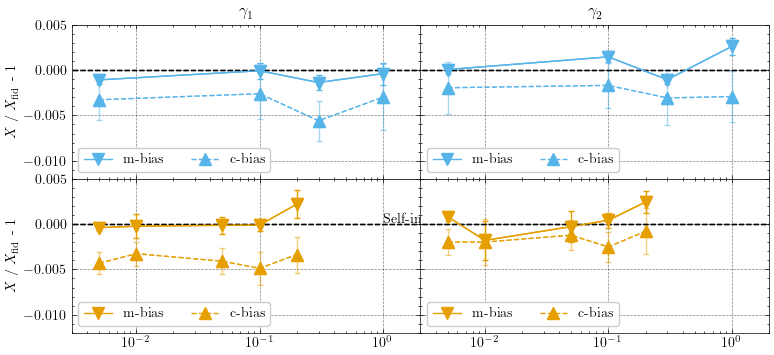

In [29]:
config='baha2dark'
filter_list  = ['concat']
cdm = 5e-3

ifilter='concat'

domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


output_name = f"pickles/shape_measurement_{ifilter}_test.pkl"

all_tests = pkl.load(open(output_name,'rb'))


fig, axarr = plt.subplots(2,2, figsize=(9,4))
fig.subplots_adjust(hspace=0,wspace=0)

ax = axarr[0]


color = {
        'src':'r',
        'tgt':'b'
    }

fid =  all_tests[1]

itest = 0

for ic, c in enumerate([0, 0.01]):
    for im in enumerate([0,0.01]):
        for icomp, comp in enumerate(['e1','e2']):
            
            
            itest += 1
    
            
            all_results = all_tests[itest]


            if all_results['bias'][comp]['m'] ==  all_results['bias'][comp]['c']:
                continue
            
            if all_results['bias'][comp]['m']  > 0:
                fmt='-v'
                label='m-bias'
                alpha=1
            else:
                fmt='--^'
                label='c-bias'
                alpha=0.5
            
            for itgt, target in enumerate(['src','tgt']):
                all_thresholds = []
                ax = axarr[itgt, icomp]
                for imodel in all_results.keys():
                    if imodel == 'bias':
                        continue


                    tgt = get_threshold_for_cross( 
                        all_results[imodel][target], 
                        mass_cut=None, 
                        dataset=domain[target].split('_')[0],
                        quiet=False)

                    ref = get_threshold_for_cross( 
                        fid[imodel][target], 
                        mass_cut=None, 
                        dataset=domain[target].split('_')[0],
                        quiet=False)

                    all_thresholds.append(tgt['thresholds']/ref['thresholds'])

                all_thresholds = np.array(all_thresholds)
                means = np.nanmean(all_thresholds,axis=0)
                errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 





                tgt['cross_sections'][0] += cdm
                ax.errorbar( tgt['cross_sections'], 
                            means-1,
                            errors,
                            fmt=fmt, 
                            capsize=2,
                            markersize=8,
                           color=colour_scheme[domain[target].split('_')[0]],
                           alpha=alpha)
                ax.plot( tgt['cross_sections'], 
                            means-1,
                            fmt, 
                            markersize=8, 
                            color=colour_scheme[domain[target].split('_')[0]],
                           label=label)
                
                
                ax.legend(loc=3, ncols=2)
                ax.plot([1e-4,10],[0,0],'k--')
                
                ax.set_xscale('log')
                ax.set_xlim(3e-3,2)
                
                if itgt == 0:
                    ax.set_title(f"$\{comp.replace('e','gamma_')}$")
            #ax.set_xscale('log')
                #if itgt == 1:

                    #ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
                    
                    
                axarr[icomp,0].set_ylabel("$X$ / $X_{\\rm fid}$ - 1")
                ax.set_ylim(-0.012,0.005)
                
                if icomp == 1:
                    ax.set_yticklabels([])
                    
                if itgt == 0:
                    ax.set_xticklabels([])
                    
                
            #ax.set_ylabel("Model threshold output")

            #
            #ax.set_xlim(3e-3,1)
            #ax.text(0.05,0.85,f"{isource_redshift}", transform=ax.transAxes,fontsize=12)
           
        #plot_observations( "pickles/model_on_data.pkl", 'concat', ax=ax, correction=3.6, fill_args={'alpha':0.2} )


axarr[icomp,0].text( 1.0,0.,"Self-interaction Cross-Section") 

fname="plots/shape_measurement_bias.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

## C) Mass dependence 

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 17.03it/s]


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/mass_dependency.pdf'.


0

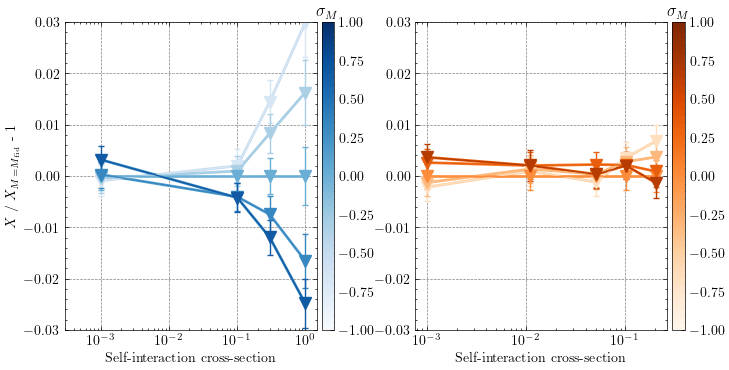

In [30]:
output_name = "pickles/mass_data_dependence.pkl"

mass_results = pkl.load(open(output_name, 'rb'))
n_mass_bins = len(list(mass_results.keys()))
fig, axarr = plt.subplots(1, 2, figsize=(8,4))
fig.subplots_adjust(wspace=.3)
color = {
    'src':colourFromRange([-1,n_mass_bins], cmap='Blues'),
    'tgt':colourFromRange([-1,n_mass_bins], cmap='Oranges')
}
                           
                           
ref = {'src':np.mean(1-mass_results[2]['src']['thresholds'], axis=0),
       'tgt':np.mean(1-mass_results[2]['tgt']['thresholds'], axis=0)
      }

for imass_bin in tqdm(range(n_mass_bins)):
    
      
        
    for itgt, target in enumerate(['src','tgt']):
  
        ax = axarr[ itgt ]

        all_thresholds = mass_results[imass_bin][target]['thresholds']
        cross_sections =  mass_results[imass_bin][target]['cross_section']

            
        means = np.mean(1-all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0)/np.sqrt(all_thresholds.shape[0])
  
        cross_sections  =  mass_results[imass_bin][target]['cross_section']
  
        
        ax.errorbar( cross_sections+1e-3, 
                    means/ref[target] -1,
                    errors/ref[target],
                    fmt='-v', label=f"${mass_cut[0]}$", 
                    capsize=2,
                    markersize=8, color=color[target][imass_bin])

       
            
            
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    
        points = np.column_stack([cross_sections+1e-3, means/ref[target]-1])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(-1, 1 ),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], imass_bin/n_mass_bins-0.5))
        im2 = ax.add_collection(lc)


        ax.set_xscale('log')

        ax.set_xlabel("Self-interaction cross-section")
        if imass_bin == 0:
            if itgt == 0:
                ax.set_ylabel("Model threshold output")

        if imass_bin == n_mass_bins - 1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            fig.colorbar(im2, cax=cax, orientation='vertical')           
            ax.text(1.04,1.02,"$\sigma_M$",transform=ax.transAxes,fontsize=12, ha='center')
        ax.set_ylim(-0.03,0.03)
axarr[0].set_ylabel("$X$ / $X_{M=M_{\\rm fid}}$ - 1")
fname = "plots/mass_dependency.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")